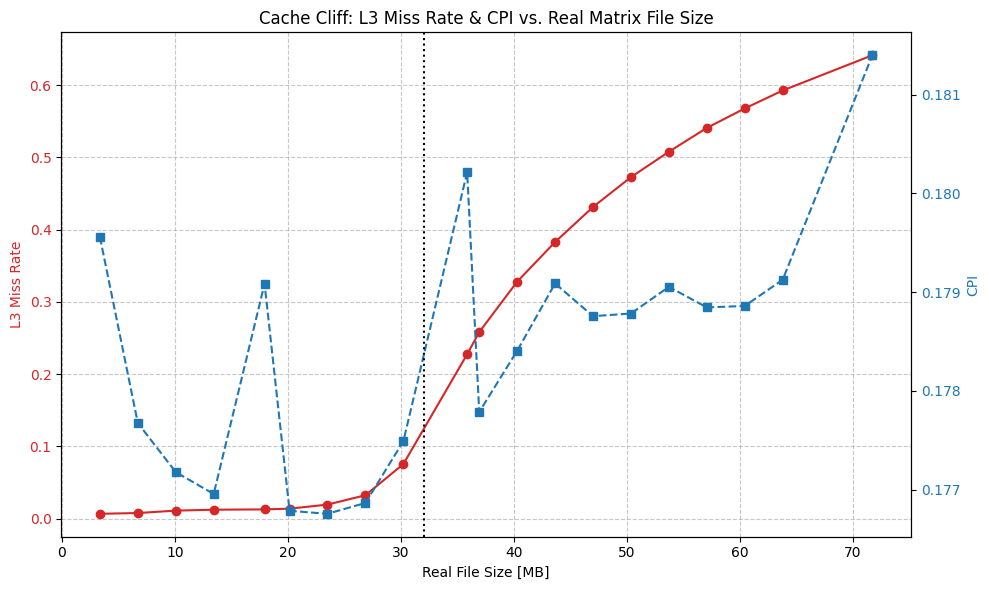

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

csv_path = '/home/mengelsl/MA-bench-framework/cachefit_testing/outputs/spmv_20260201_161838/summary.csv'
matrix_dir = '/home/mengelsl/MA-bench-framework/cachefit_testing/matrices'

df = pd.read_csv(csv_path)

df['CPI'] = df['Clks'] / df['Inst']
df['MissRate'] = df['L3_Miss'] / (df['L3_Hit'] + df['L3_Miss'])

df_clean = df.groupby('N').median().reset_index()

def get_file_size(n):
    file_path = os.path.join(matrix_dir, f"band_N{n}.bin")
    if os.path.exists(file_path):
        return os.path.getsize(file_path) / (1024**2)
    return None

df_clean['MB'] = df_clean['N'].apply(get_file_size)
df_clean = df_clean.dropna(subset=['MB'])

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Real File Size [MB]')
ax1.set_ylabel('L3 Miss Rate', color='tab:red')
ax1.plot(df_clean['MB'], df_clean['MissRate'], 'o-', color='tab:red', label='L3 Miss Rate')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.grid(True, linestyle='--', alpha=0.7)

ax2 = ax1.twinx()
ax2.set_ylabel('CPI', color='tab:blue')
ax2.plot(df_clean['MB'], df_clean['CPI'], 's--', color='tab:blue', label='CPI')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.axvline(x=32, color='black', linestyle=':', label='L3 Boundary (32MB)')
plt.title('Cache Cliff: L3 Miss Rate & CPI vs. Real Matrix File Size')
fig.tight_layout()
plt.show()